## NAME: BHAVISHA BHANUSHALI   ROLL NO.:06
## BATCH:A1          DATE:11/02/26

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

In [10]:
data=pd.read_csv("credit.csv", skiprows=1)
data=data.sample(5000, random_state=36)
print(data.columns)
print(data.info())
print(data.describe())
print(data.head())
print(data.tail())
print(data.shape) 


      


Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 17237 to 9437
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          5000 non-null   int64
 1   LIMIT_BAL                   5000 non-null   int64
 2   GENDER                      5000 non-null   int64
 3   EDUCATION                   5000 non-null   int64
 4   MARRIAGE                    5000 non-null   int64
 5   AGE                         5000 non-null   int64
 6   PAY_0                       5000 non-null   int64
 7   PAY_2                       5000 non-null

In [11]:
data.isnull().sum()

ID                            0
LIMIT_BAL                     0
GENDER                        0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [12]:
print(data.dtypes)

ID                            int64
LIMIT_BAL                     int64
GENDER                        int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object


In [13]:
y=data['default payment next month']
x=data[['BILL_AMT1', 'BILL_AMT2']]
print(data.dtypes)
print(data.head())


ID                            int64
LIMIT_BAL                     int64
GENDER                        int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object
          ID  LIMIT_BAL  GENDER  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  \
17237  1723

In [14]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=36)

In [15]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [16]:

models = {
    "Linear SVM": SVC(kernel='linear', C=1, class_weight='balanced'),
   
    "Polynomial SVM": SVC(kernel='poly',
                          degree=2,
                          C=1,
                          gamma='scale',
                          class_weight='balanced'),
   
    "RBF SVM": SVC(kernel='rbf',
                   C=5,
                   gamma=0.1,
                   class_weight='balanced')
}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    print("\n", name)
    print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred))
    print("Acuracy:", accuracy_score(y_test, y_pred))
    print("F1 score:", f1_score(y_test, y_pred))


 Linear SVM
Confusion Matrix: [[ 153 1028]
 [  35  284]]
Precision: 0.21646341463414634
Recall: 0.890282131661442
Acuracy: 0.29133333333333333
F1 score: 0.3482526057633354

 Polynomial SVM
Confusion Matrix: [[  27 1154]
 [   7  312]]
Precision: 0.21282401091405184
Recall: 0.9780564263322884
Acuracy: 0.226
F1 score: 0.3495798319327731

 RBF SVM
Confusion Matrix: [[245 936]
 [ 50 269]]
Precision: 0.2232365145228216
Recall: 0.8432601880877743
Acuracy: 0.3426666666666667
F1 score: 0.3530183727034121


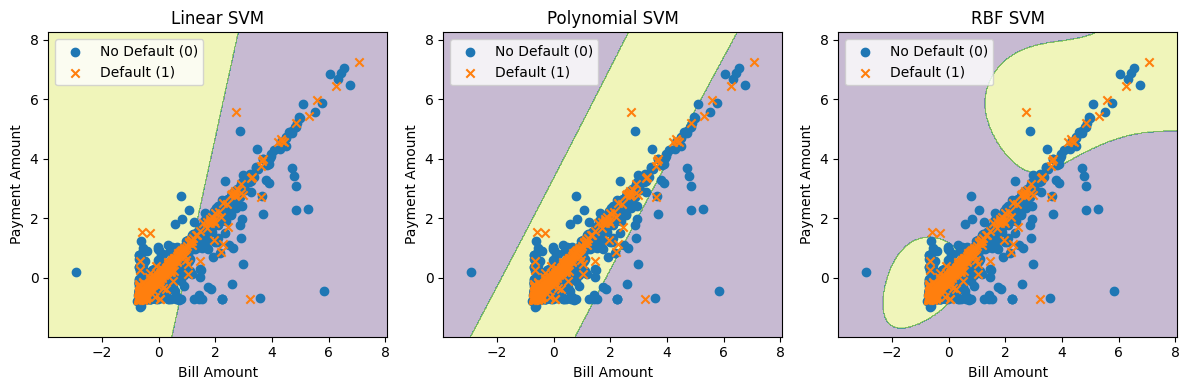

In [20]:
# --- Decision Boundary Plotting Function ---
def plot_boundary(model, title):
    h = 0.02
    x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
    y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
   
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
   
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
   
    plt.contourf(xx, yy, Z, alpha=0.3)
   
    # Class 0
    plt.scatter(x_train[y_train == 0, 0],
                x_train[y_train == 0, 1],
                label='No Default (0)',
                marker='o')
   
    # Class 1
    plt.scatter(x_train[y_train == 1, 0],
                x_train[y_train == 1, 1],
                label='Default (1)',
                marker='x')
   
    plt.legend()
    plt.title(title)
    plt.xlabel("Bill Amount")
    plt.ylabel("Payment Amount")

# --- Model Training and Execution ---
plt.figure(figsize=(12, 4))

for i , (name,model) in enumerate(models.items()):
    plt.subplot(1,3,i+1)
    model.fit(x_train, y_train)
    plot_boundary(model, name)
plt.tight_layout()
plt.show()
    